## Results from decay_endmax_fidelity.jld2

In [1]:
using Plots, JLD2, LaTeXStrings, FileIO

@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/results_data/2atoms/decay_endmax_fidelity.jld2"
# @load "C:/Users/14aka/OneDrive/Documents/rydberg_qec/codework/results_data/2atoms/optimal_decay_trial1.jld2"

decay = decay
sweep_rate = sweep_rate
fidelity_end = fidelity_end
max_fidelity = max_fidelity;

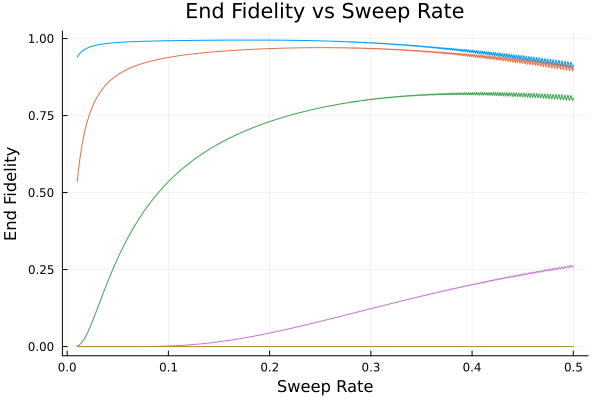

In [2]:
plot(sweep_rate,fidelity_end[1,:],label="γ = 1e-5",xlabel="Sweep Rate",ylabel="End Fidelity",title="End Fidelity vs Sweep Rate",legend=:false)
plot!(sweep_rate,fidelity_end[2,:],label="γ = 1e-4")
plot!(sweep_rate,fidelity_end[3,:],label="γ = 1e-3")
plot!(sweep_rate,fidelity_end[4,:],label="γ = 1e-2")
plot!(sweep_rate,fidelity_end[5,:],label="γ = 1e-1")

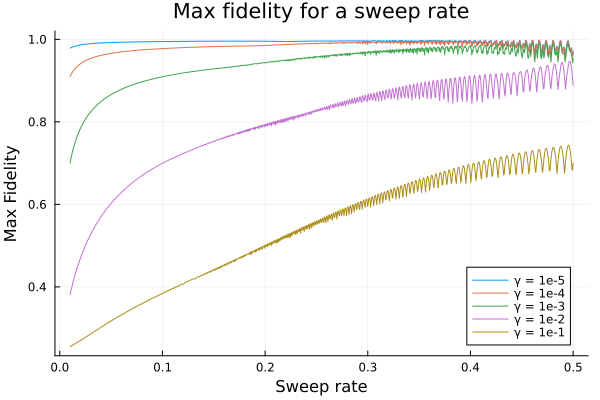

In [3]:
plot(sweep_rate,max_fidelity[1,:], label="γ = 1e-5", xlabel="Sweep rate", ylabel="Max Fidelity", title="Max fidelity for a sweep rate", legend=:bottomright)
plot!(sweep_rate,max_fidelity[2,:], label="γ = 1e-4", xlabel="Sweep rate", ylabel="Max Fidelity")
plot!(sweep_rate,max_fidelity[3,:], label="γ = 1e-3", xlabel="Sweep rate", ylabel="Max Fidelity")
plot!(sweep_rate,max_fidelity[4,:], label="γ = 1e-2", xlabel="Sweep rate", ylabel="Max Fidelity") 
plot!(sweep_rate,max_fidelity[5,:], label="γ = 1e-1", xlabel="Sweep rate", ylabel="Max Fidelity")

In [4]:
best_fidelity = maximum(max_fidelity[:,1:600],dims=2);
best_sweep_rate = []
for i in 1:length(decay)
    max_index = argmax(max_fidelity[i,1:600])
    push!(best_sweep_rate, sweep_rate[max_index])
end

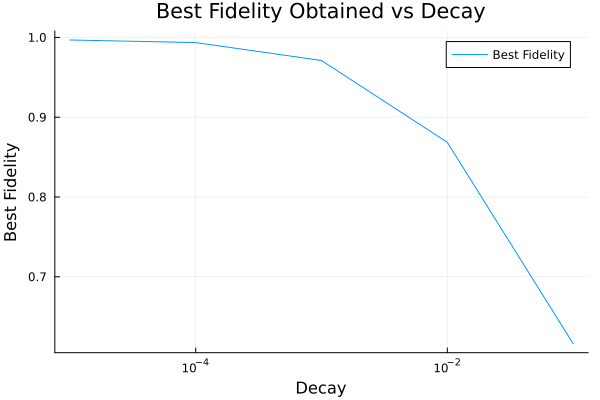

In [5]:
plot(decay,best_fidelity,xscale=:log10, label="Best Fidelity", xlabel="Decay", ylabel="Best Fidelity", title="Best Fidelity Obtained vs Decay", legend=:topright)

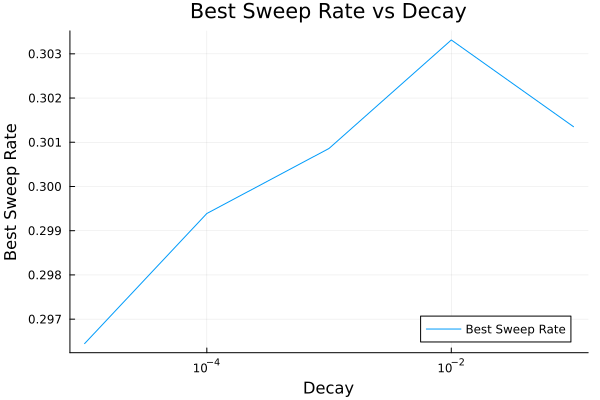

In [6]:
plot(decay,best_sweep_rate, xscale=:log10, label="Best Sweep Rate", xlabel="Decay", ylabel="Best Sweep Rate", title="Best Sweep Rate vs Decay", legend=:bottomright)

## Analytical Decay

In [16]:
l = length(decay)
m = length(sweep_rate)

analytical_fidelity = Array{Float64}(undef,l,m)

Threads.@threads for idx in 1:l*m
    i = (idx-1) ÷ m + 1  # Calculate the row index
    j = (idx-1) % m + 1  # Calculate the column index

    a = decay[i]
    b = sweep_rate[j]
    T = 2*(1031-1000)/b
    analytical_fidelity[i,j] = real((1 - exp(-1/b)) * exp(-a * 0.5*T))
end

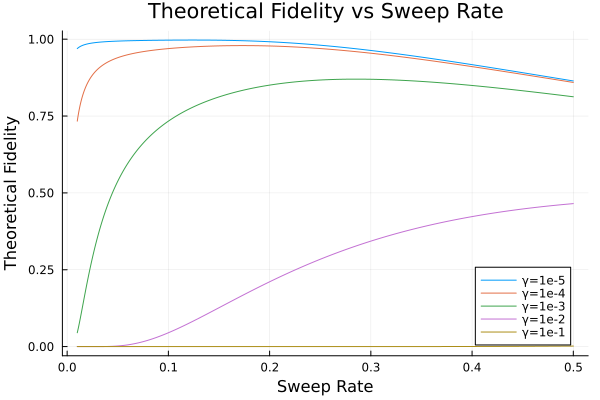

In [17]:
plot(sweep_rate,analytical_fidelity[1,:],label="γ=1e-5",xaxis="Sweep Rate",yaxis="Theoretical Fidelity",title="Theoretical Fidelity vs Sweep Rate",legend=:bottomright)
plot!(sweep_rate,analytical_fidelity[2,:],label="γ=1e-4",xaxis="Sweep Rate",yaxis="Theoretical Fidelity")
plot!(sweep_rate,analytical_fidelity[3,:],label="γ=1e-3",xaxis="Sweep Rate",yaxis="Theoretical Fidelity")
plot!(sweep_rate,analytical_fidelity[4,:],label="γ=1e-2",xaxis="Sweep Rate",yaxis="Theoretical Fidelity")
plot!(sweep_rate,analytical_fidelity[5,:],label="γ=1e-1",xaxis="Sweep Rate",yaxis="Theoretical Fidelity")

## Observations

##### 1. End Fidelity calculated Numerically get messed up after sweep_rate of 0.25 because of two reasons:
##### a. Numerical Instability of the solver
##### b. Fast Sweep implying the process is tending to be more non-adiabatic

##### 2. Theoretical End Fidelity fits almost with the Calculated End Fidelity, and the differences are because
##### a. I still need to figure this out

#### 3. The Best Sweep Rate goes linearly with increase in decay rate, approximately.
#### Note: The Best sweep rate for 10^-1 is not to be considered, given the numerical instabilities of the solver

##### 4. The Maximum Fidelity and Best Sweep Rate for a decay rate cannot be calculated analytically 